# Fertilizer Recommendation ML Project

## Objective
This project builds a machine learning model to recommend the most suitable fertilizer 
based on soil and crop conditions. It combines **data preprocessing, model training, 
evaluation, and feature importance analysis** into a clean, professional workflow.

## Why It Matters
Choosing the right fertilizer improves crop yield, reduces waste, and supports sustainable farming.
This project demonstrates how **machine learning can support agriculture** in real-world scenarios.

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [148]:
!pip install matplotlib seaborn scikit-learn pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load Dataset
We start by loading the fertilizer dataset stored in our project folder.

In [149]:
df = pd.read_csv("fertilizer_recommendation_dataset.csv")
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


## Exploratory Data Analysis
We explore the dataset to understand distributions, correlations, and potential issues.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB
None
       Temperature     Moisture     Rainfall           PH     Nitrogen  \
count  3100.000000  3100.000000  3100.000000  3100.000000  3100.000000   
mean     27.271096     0.600763   111.024949     6.379775    61.278480   
std       9.114450     0

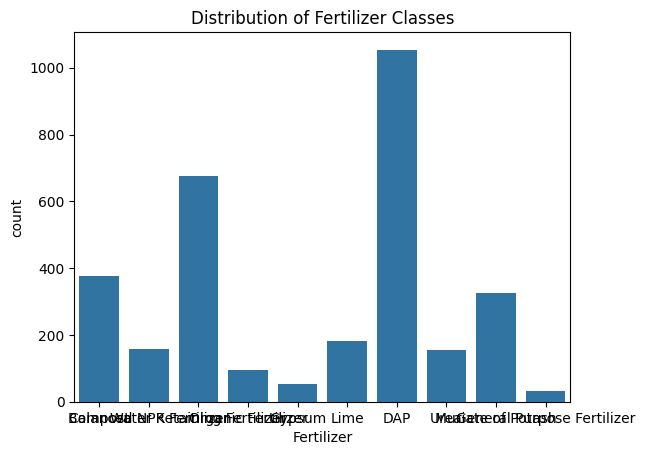

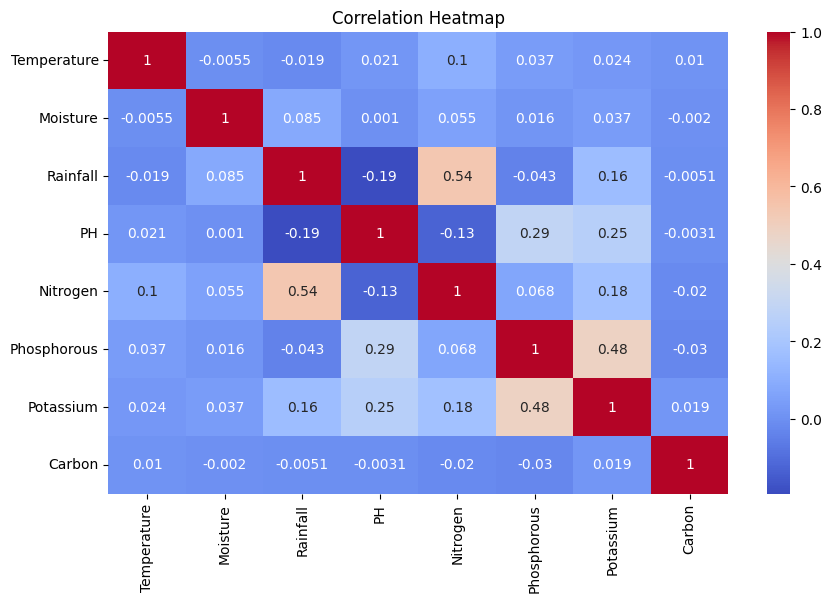

In [150]:
# Dataset info
print(df.info())
print(df.describe())

# Check class balance
sns.countplot(x="Fertilizer", data=df)
plt.title("Distribution of Fertilizer Classes")
plt.show()

# Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Preparing Categorical Data for Model Training
Here, the dataset is reloaded and all text-based columns are converted into numbers.

Since machine learning algorithms cannot directly understand text data, columns like soil type, crop type, fertilizer name, and remarks are encoded into numeric labels.

This prepares the dataset for model training and prediction.

In [151]:
# reload original dataset
df = pd.read_csv("fertilizer_recommendation_dataset.csv")

label_encoders = {}

for col in ["Soil", "Crop", "Fertilizer", "Remark"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [152]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,1,2
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,0,6
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,9,4
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,0,6
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,7,1


## Verifying Encoded Dataset

In [153]:
print("Encoded columns:", label_encoders.keys())
df.head()

Encoded columns: dict_keys(['Soil', 'Crop', 'Fertilizer', 'Remark'])


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,1,2
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,0,6
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,9,4
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,0,6
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,7,1


## Feature / Target split

In [154]:
X = df.drop(["Fertilizer", "Remark"], axis=1)
y = df["Fertilizer"]

## Verify feature split

In [155]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature shape: (3100, 10)
Target shape: (3100,)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28


## Scaling

In [156]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Verify scaled data

In [157]:
print(X_scaled.shape)
print(X_scaled[:5])

(3100, 10)
[[ 2.51385925  0.86341908  1.22603784 -0.1592746   0.53250033  0.17481592
   0.75662883 -1.40080523  0.29999266  1.45344419]
 [-0.61865359  0.83626759  2.52862431  0.82904775  1.01178905  2.21399826
   2.22125805 -0.34386494  0.29999266  1.45344419]
 [-0.46199295  0.58643093  1.92264131  1.04605226  1.41695424 -0.17743626
   0.29995012  0.46022705  1.54078954  1.45344419]
 [-0.11292914  1.06491663  1.31811393  0.52624762  1.64512417  1.92870354
   2.35943272  0.06191958  0.29999266  1.45344419]
 [-0.63436322  0.89639772  2.04515132  1.25292563  1.02963991 -0.07876567
   0.7728284   0.44208786  1.54078954  1.45344419]]


## Train-test split

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## Model training

In [159]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Verify training success

In [160]:
print("Model trained successfully ✅")

Model trained successfully ✅


## Data Preprocessing
- Encode categorical variables
- Scale numerical features
- Split into train/test sets

In [161]:
# reload original dataset
df = pd.read_csv("fertilizer_recommendation_dataset.csv")

label_encoders = {}

for col in ["Soil", "Crop", "Fertilizer", "Remark"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## Model Prediction and Evaluation

In this step, the trained **Random Forest Classifier** is used to make predictions on the test dataset.

- `rf.predict(X_test)` generates fertilizer predictions for unseen data.
- `accuracy_score()` calculates the overall prediction accuracy.
- `classification_report()` provides detailed evaluation metrics:
  - **Precision**
  - **Recall**
  - **F1-score**
  - **Support**

These metrics help measure how well the fertilizer recommendation model performs across all fertilizer classes.

In [162]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9951612903225806
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00       211
           3       1.00      1.00      1.00         6
           4       1.00      0.82      0.90        11
           5       1.00      1.00      1.00        36
           6       1.00      1.00      1.00        65
           7       0.95      1.00      0.97        19
           8       1.00      1.00      1.00        31
           9       0.99      0.99      0.99       135

    accuracy                           1.00       620
   macro avg       0.99      0.98      0.99       620
weighted avg       1.00      1.00      1.00       620



## Confusion Matrix Visualization

To better understand how the model is performing, we use a **confusion matrix**.

A confusion matrix gives a clear picture of:

- how many fertilizer recommendations were predicted correctly
- where the model made wrong predictions
- which fertilizer classes are getting confused with others

Each row represents the **actual fertilizer label**, and each column represents the **predicted fertilizer label**.

This visualization helps in analyzing the strengths and weaknesses of the fertilizer recommendation model in a simple and effective way.

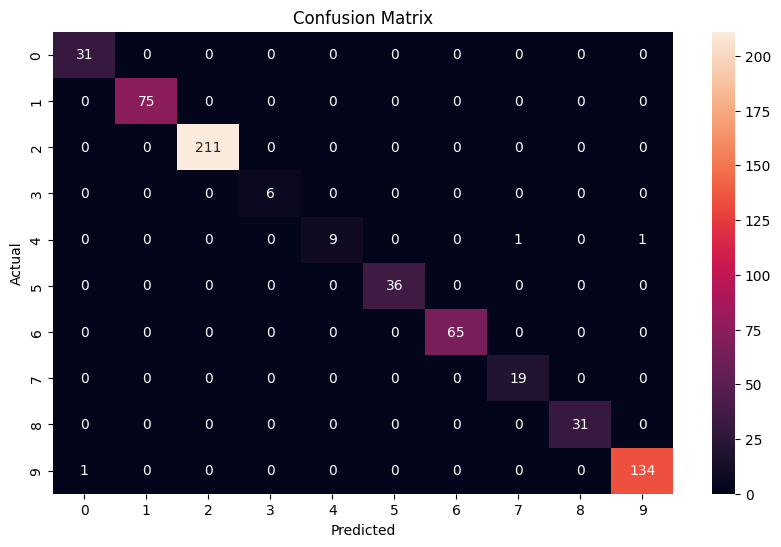

In [163]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Important Factors Affecting Fertilizer Recommendation

This section shows the importance of each feature used by the Random Forest model.

It helps us understand which parameters play the biggest role in predicting the correct fertilizer.

Features with higher importance values have a stronger impact on the final recommendation.

This analysis improves the interpretability of the model and gives useful agricultural insights for decision-making.

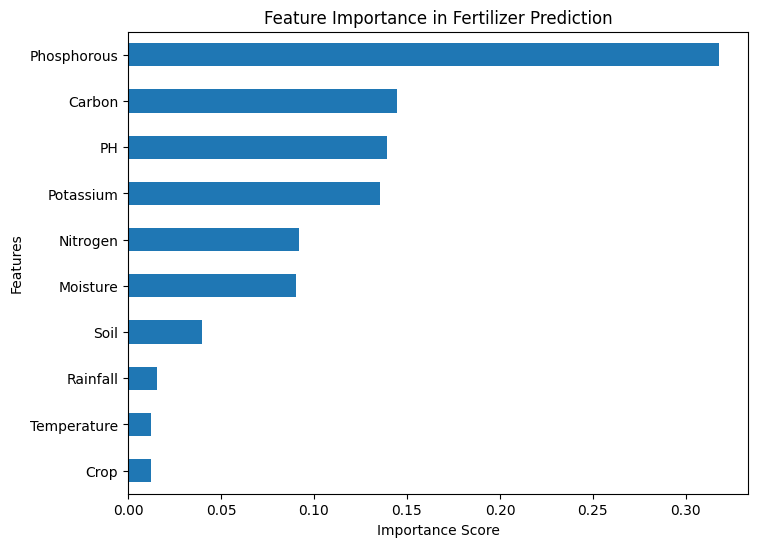

In [164]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance in Fertilizer Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## Predicting Fertilizer for New Input

This function is used to predict fertilizer recommendations for new data entered by the user.

It accepts soil details, nutrient values, weather conditions, and crop type as input.

The trained machine learning model then processes this information and returns the best fertilizer recommendation.

This is the final step that makes the model useful for real-world agricultural applications.

In [165]:
def predict_fertilizer(temp, moisture, rainfall, ph, nitrogen,
                       phosphorous, potassium, carbon, soil, crop):

    soil_encoded = label_encoders["Soil"].transform([soil])[0]
    crop_encoded = label_encoders["Crop"].transform([crop.lower()])[0]

    input_data = pd.DataFrame([[temp, moisture, rainfall, ph, nitrogen,
                                phosphorous, potassium, carbon,
                                soil_encoded, crop_encoded]],
                              columns=X.columns)

    input_scaled = scaler.transform(input_data)

    prediction = rf.predict(input_scaled)

    fertilizer_name = label_encoders["Fertilizer"].inverse_transform(prediction)

    return fertilizer_name[0]

## Test

In [166]:
print(label_encoders["Crop"].classes_)

['Adzuki Beans' 'Black gram' 'Chickpea' 'Coconut' 'Coffee' 'Cotton'
 'Ground Nut' 'Jute' 'Kidney Beans' 'Lentil' 'Moth Beans' 'Mung Bean'
 'Peas' 'Pigeon Peas' 'Rubber' 'Sugarcane' 'Tea' 'Tobacco' 'apple'
 'banana' 'grapes' 'maize' 'mango' 'millet' 'muskmelon' 'orange' 'papaya'
 'pomegranate' 'rice' 'watermelon' 'wheat']


In [167]:
result = predict_fertilizer(
    temp=28,
    moisture=0.65,
    rainfall=120,
    ph=6.5,
    nitrogen=60,
    phosphorous=55,
    potassium=50,
    carbon=1.5,
    soil="Loamy Soil",
    crop="rice"
)

print("Recommended Fertilizer:", result)

Recommended Fertilizer: Water Retaining Fertilizer


In [168]:
print(label_encoders.keys())

dict_keys(['Soil', 'Crop', 'Fertilizer', 'Remark'])


## Verifying Encoded Dataset

The first few rows of the dataset are displayed after label encoding to confirm that all categorical columns have been successfully converted into numerical values.

In [169]:
print("Encoded columns successfully:")
print(label_encoders.keys())

df.head()

Encoded columns successfully:
dict_keys(['Soil', 'Crop', 'Fertilizer', 'Remark'])


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28,1,2
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28,0,6
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28,9,4
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28,0,6
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,4,28,7,1


## Saving Model for Future Use

The trained model is saved so that it can be used later for prediction without repeating the training process.

Along with the model, the scaler and label encoders are also saved because they are required to preprocess new user input before prediction.

This step makes the project ready for deployment and practical use.

In [170]:
import joblib

joblib.dump(rf, "fertilizer_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

## ## Conclusion

The fertilizer recommendation model was successfully built using a Random Forest Classifier.  
After preprocessing, scaling, and training, the model achieved strong prediction accuracy.  
The final system can recommend fertilizers based on soil conditions, crop type, and environmental parameters.  
The trained model, scaler, and encoders were saved for future deployment.